# **Upper Confidence Bound from Scratch**

## 0.ライブラリのインポートとデータの生成

In [17]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
true_probs = [0.2, 0.35, 0.5, 0.65, 0.8]
n_bandits = len(true_probs)
n_rounds = 1000

## 1.アルゴリズム

多腕バンディット問題における探索(exploration)と活用(exploitation)のトレードオフを解決するアルゴリズム。信頼区間の上限が最も大きいスロットを選び続けることで、累積報酬を最大化する。

### 1.1.UCB

信頼区間の上限が最も大きいスロットを選ぶ。試行回数が少ないスロットは不確実性が高いため、信頼区間が広くなり選ばれやすくなる。
$$UCB_i(n) = \frac{R_i(n)}{N_i(n)} + \sqrt{\frac{3}{2} \cdot \frac{\log n}{N_i(n)}}$$
この式はホフディングの不等式から導かれ、真の平均が信頼区間の上限を超える確率を抑えながら、楽観的に上限を選ぶ。

In [18]:
def ucb(n_bandits, n_rounds, true_probs):
  N = np.zeros(n_bandits)
  R = np.zeros(n_bandits)
  choices = []
  rewards = []
  regrets = []

  best_prob = max(true_probs)

  for i in range(n_bandits):
    reward = np.random.binomial(1, true_probs[i])
    N[i] += 1
    R[i] += reward

  for n in range(n_bandits, n_rounds):
    ucb_values = R / N + np.sqrt(3/2 * np.log(n) / N)
    chosen = np.argmax(ucb_values)
    reward = np.random.binomial(1, true_probs[chosen])
    N[chosen] += 1
    R[chosen] += reward
    choices.append(chosen)
    rewards.append(reward)
    regrets.append(best_prob - true_probs[chosen])

  return choices, rewards, N, R, regrets

choices, rewards, N, R, regrets = ucb(n_bandits, n_rounds, true_probs)

## 2.モデルの可視化

### 2.1.各スロットの選択回数

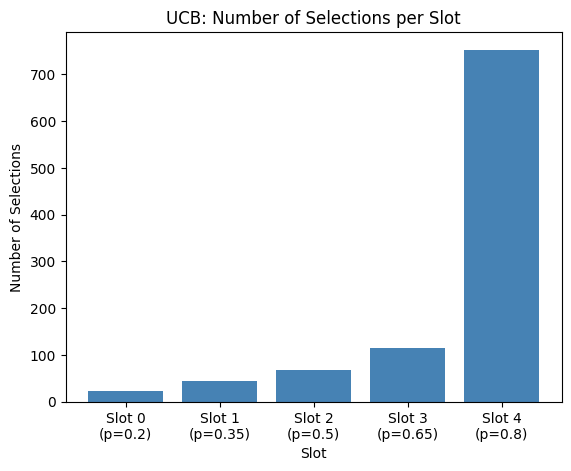

In [19]:
plt.bar(range(n_bandits), N, color='steelblue')
plt.xticks(range(n_bandits), [f'Slot {i}\n(p={true_probs[i]})' for i in range(n_bandits)])
plt.xlabel("Slot")
plt.ylabel("Number of Selections")
plt.title("UCB: Number of Selections per Slot")
plt.show()

### 2.2.累積報酬の推移

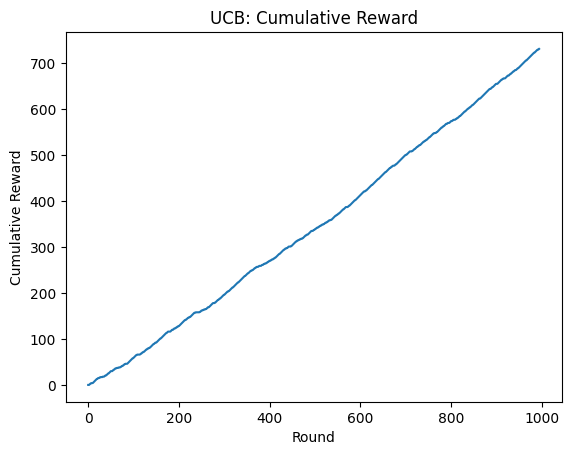

In [20]:
cumulative_rewards = np.cumsum(rewards)
plt.plot(cumulative_rewards)
plt.xlabel("Round")
plt.ylabel("Cumulative Reward")
plt.title("UCB: Cumulative Reward")
plt.show()

## 3.検証

### 3.1.regretの推移

最適なスロットを選び続けた場合との報酬の差をregretと呼ぶ。
$$\text{regret}(n) = \mu^* - \mu_{c_n}$$

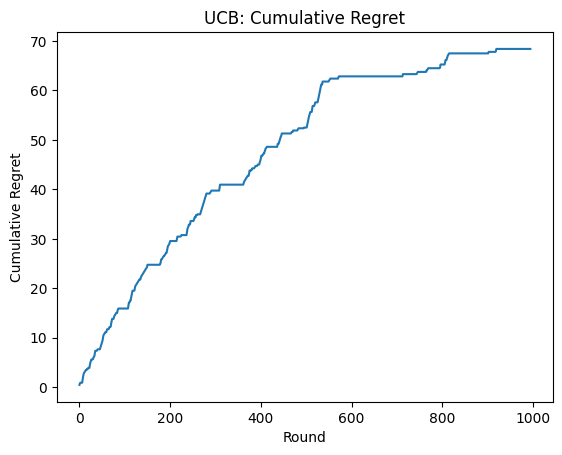

In [21]:
cumulative_regret = np.cumsum(regrets)
plt.plot(cumulative_regret)
plt.xlabel("Round")
plt.ylabel("Cumulative Regret")
plt.title("UCB: Cumulative Regret")
plt.show()